In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import datetime

In [2]:
data =pd.read_csv('netflix1.csv')
print(data.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [12]:
print(data.isnull().sum().sum())

0


In [16]:
data.drop_duplicates(inplace=True)

In [17]:
data.dropna(inplace = True)

In [21]:
print(data.dtypes)

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object


In [5]:
data['date_added']=pd.to_datetime(data['date_added'])

# (EDA)

In [5]:
tycount=data['type'].value_counts()

C:\Users\cc\AppData\Local\Temp\ipykernel_7020\3493451125.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tycount.index,y=tycount.values,palette="Set3" )


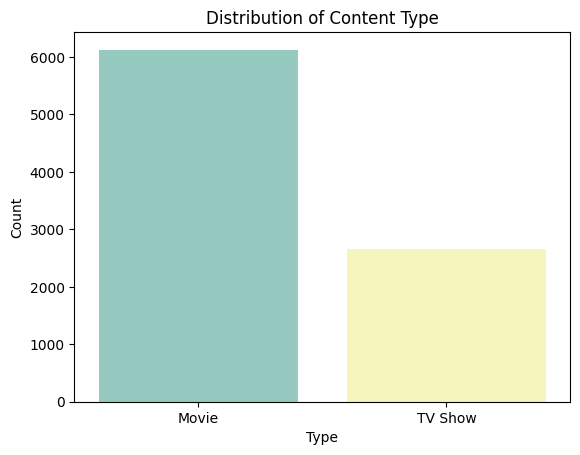

In [7]:
sns.barplot(x=tycount.index,y=tycount.values,palette="Set3" )
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Content Type')
plt.show()

In [4]:
data['genres'] = data['listed_in'].apply(lambda x: x.split(','))
all_genres = sum(data['genres'], [])
genre_counts = pd.Series(all_genres).value_counts().head(10)


C:\Users\cc\AppData\Local\Temp\ipykernel_11088\810423553.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index,palette='Set3',legend ='False')


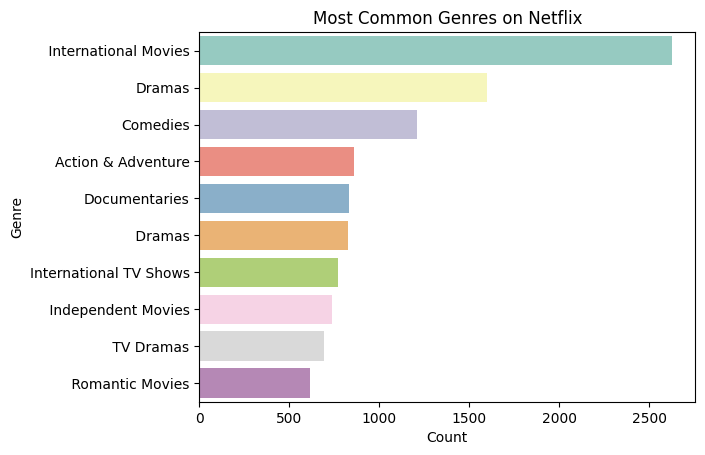

In [14]:
sns.barplot(x=genre_counts.values, y=genre_counts.index,palette='Set3')
plt.title('Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()



C:\Users\cc\AppData\Local\Temp\ipykernel_1112\2644021945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.index, y=top_directors.values,palette='muted')


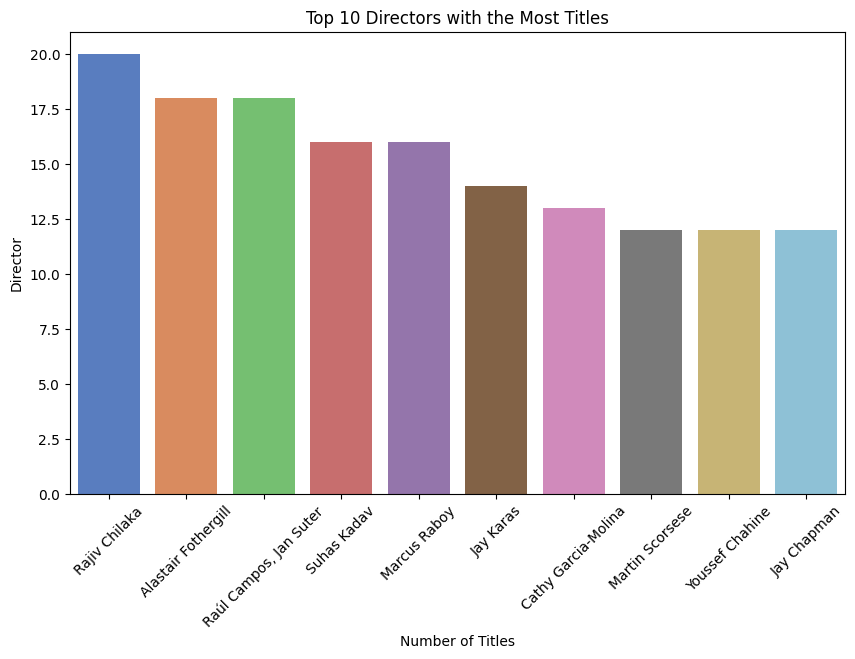

In [29]:
 top_directors = data['director'].value_counts()[1:11]
 plt.figure(figsize=(10, 6))
 sns.barplot(x=top_directors.index, y=top_directors.values,palette='muted')
 plt.xticks(rotation=45)
 plt.title('Top 10 Directors with the Most Titles')
 plt.xlabel('Number of Titles')
 plt.ylabel('Director')
 plt.show()

C:\Users\cc\AppData\Local\Temp\ipykernel_1112\2353860790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_country.values,y=count_country.index,palette='muted')


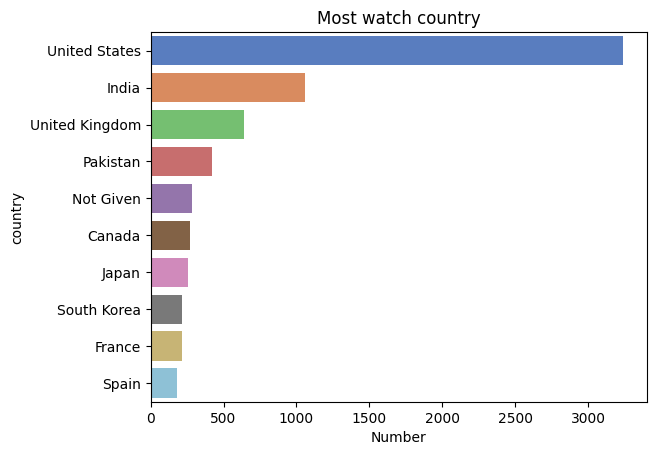

In [10]:
count_country=data['country'].value_counts().head(10)
sns.barplot(x=count_country.values,y=count_country.index,palette='muted')
plt.xlabel('Number')
plt.ylabel('country')
plt.title('Most watch country')
plt.show()

C:\Users\cc\AppData\Local\Temp\ipykernel_1112\1899068817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=release.index,y=release.values,palette='bright')


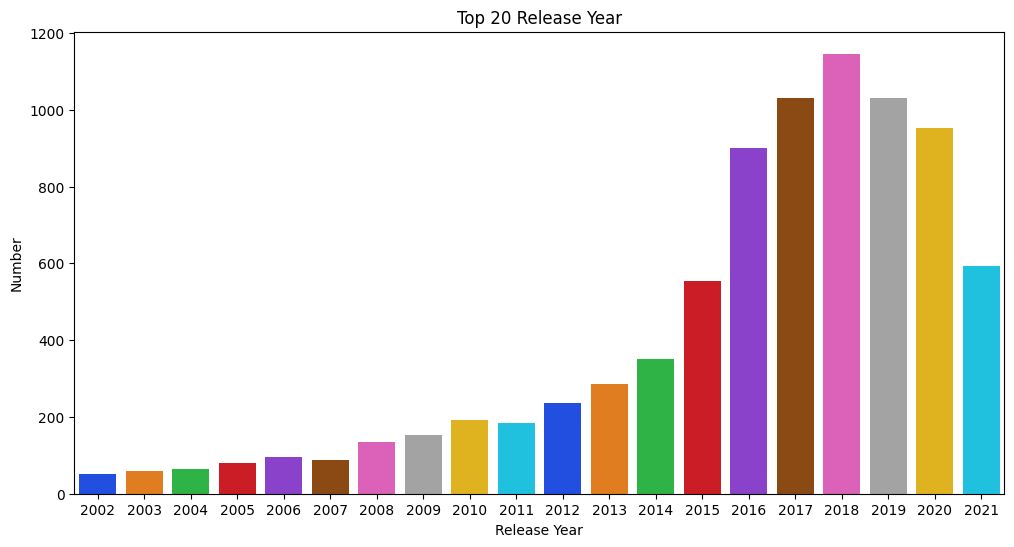

In [9]:
plt.figure(figsize=(12, 6))
release=data['release_year'].value_counts().head(20)
sns.barplot(x=release.index,y=release.values,palette='bright')
plt.xlabel('Release Year')
plt.ylabel('Number')
plt.title('Top 20 Release Year')
plt.show()

C:\Users\cc\AppData\Local\Temp\ipykernel_1112\351738715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating.index,y=rating.values,palette='Set3')


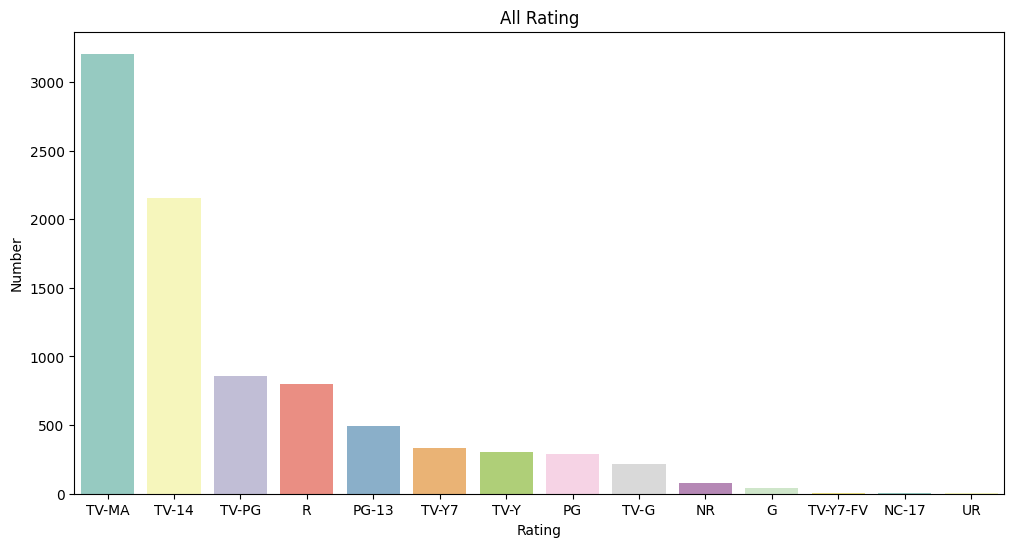

In [30]:
plt.figure(figsize=(12,6))
rating=data['rating'].value_counts()
sns.barplot(x=rating.index,y=rating.values,palette='Set3')
plt.title('All Rating')
plt.xlabel('Rating')
plt.ylabel('Number')
plt.show()

In [7]:
data['content_age']=(data['year']-data['release_year'])

C:\Users\cc\AppData\Local\Temp\ipykernel_13112\2420357516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age.index,y=age.values,palette='Set3')


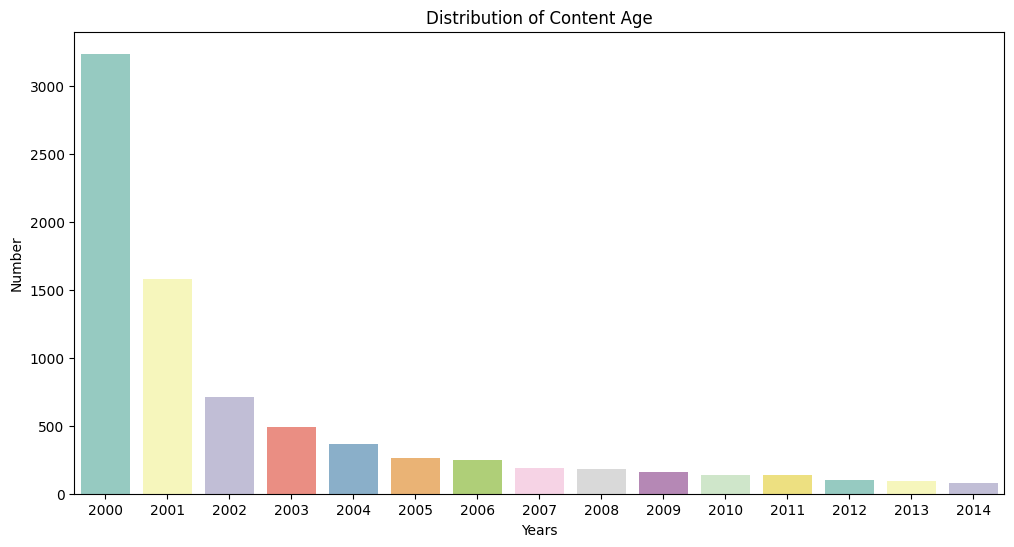

In [25]:
plt.figure(figsize=(12,6))
age=data['content_age'].value_counts().head(15)
sns.barplot(x=age.index,y=age.values,palette='Set3')
plt.xticks(range(0,15),(range(2000,2015)))
plt.title('Distribution of Content Age')
plt.xlabel('Years')
plt.ylabel('Number')

plt.show()

In [6]:
data['month']=data['date_added'].dt.month
data['year']=data['date_added'].dt.year
data['day']=data['date_added'].dt.day

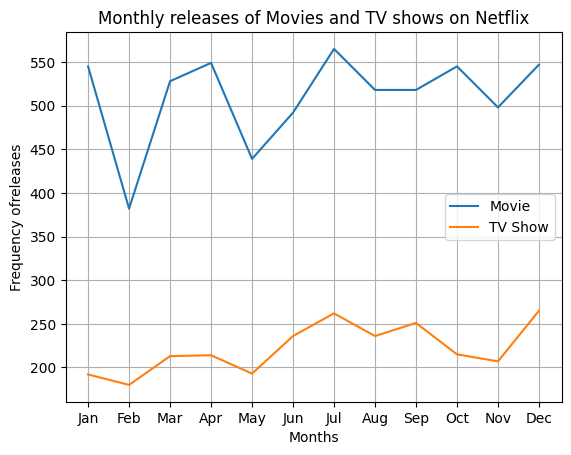

In [43]:
monthM=data[data['type']=='Movie'] ['month'].value_counts().sort_index() # SORT_INDEX IS  sort a DataFrame or Series based on the index.
monthT=data[data['type']=='TV Show']['month'].value_counts().sort_index()
plt.plot(monthM.index,monthM.values,label='Movie') 
plt.plot(monthT.index,monthT.values,label='TV Show')
plt.xlabel('Months')
plt.ylabel('Frequency ofreleases')
plt.title('Monthly releases of Movies and TV shows on Netflix')
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May',
'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid()
plt.legend()
plt.show()

In [39]:
yearM=data[data['type']=='Movie'] ['year'].value_counts().sort_index()
yearT=data[data['type']=='TV Show'] ['year'].value_counts().sort_index()

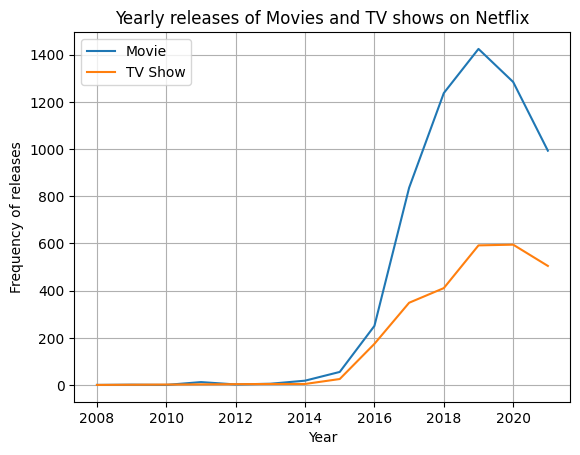

In [48]:
plt.plot(yearM.index,yearM.values,label='Movie')
plt.plot(yearT.index,yearT.values,label='TV Show')
plt.xlabel('Year')
plt.ylabel('Frequency of releases')
plt.title('Yearly releases of Movies and TV shows on Netflix')
plt.grid()
plt.legend()
plt.show()

In [46]:
dayM=data[data['type']=='Movie'] ['day'].value_counts().sort_index()
dayT=data[data['type']=='TV Show'] ['day'].value_counts().sort_index()

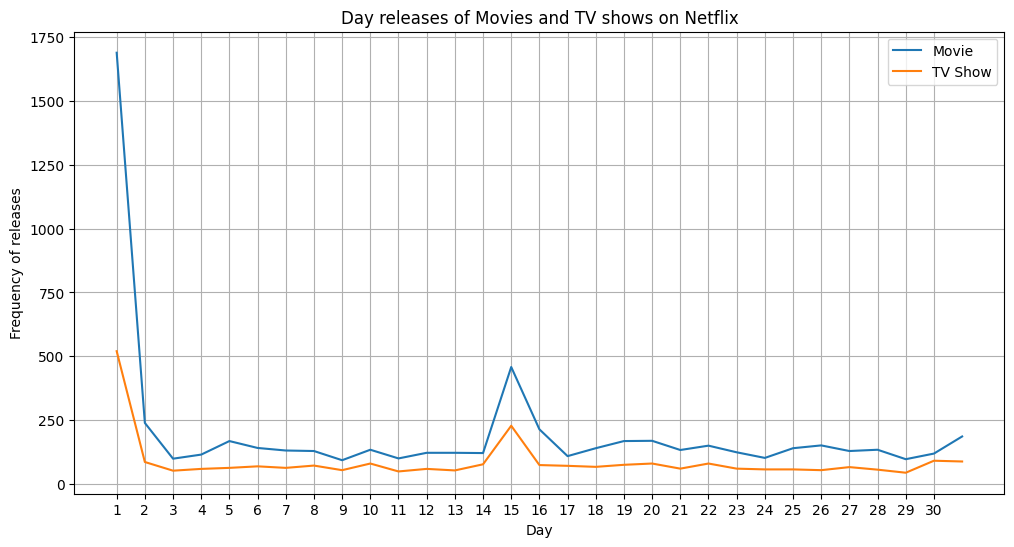

In [55]:
plt.figure(figsize=(12,6))
plt.plot(dayM.index,dayM.values,label='Movie')
plt.plot(dayT.index,dayT.values,label='TV Show')
plt.xlabel('Day')
plt.ylabel('Frequency of releases')
plt.title('Day releases of Movies and TV shows on Netflix')
plt.xticks(range(1,31))
plt.grid()
plt.legend()
plt.show()

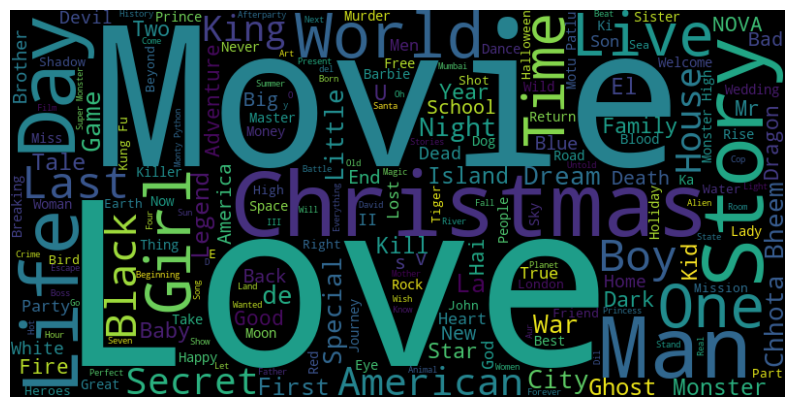

In [14]:
 movie_titles = data[data['type'] == 'Movie']['title']
 wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(movie_titles))
 # Plot word cloud
 plt.figure(figsize=(10, 6))
 plt.imshow(wordcloud, interpolation='bilinear')
 plt.axis('off')
 plt.show()